# K-Means Clustering Project – Iris Dataset

## Objective
Apply **K-Means Clustering** to the Iris dataset and evaluate clustering for different values of **K**.

The known Iris species labels are used **only for post-hoc evaluation**, not for fitting K-Means.

**Goal:** Compare K = 2, 3, 4 and 5 and use **K = 3** as the final Iris clustering configuration because the Iris dataset contains three known species.


## 1. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from scipy.stats import mode

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 2. Load the Iris Dataset


In [2]:
# Try Iris.csv first. If it is unavailable, use sklearn's built-in Iris dataset.
try:
    df = pd.read_csv('Iris.csv')
    print('Dataset loaded from Iris.csv')
except FileNotFoundError:
    from sklearn.datasets import load_iris
    iris = load_iris()
    df = pd.DataFrame(
        iris.data,
        columns=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
    )
    df['Species'] = [iris.target_names[i] for i in iris.target]
    print('Iris.csv not found. sklearn built-in Iris dataset loaded.')

print('Dataset shape:', df.shape)
df.head()


Dataset loaded from Iris.csv
Dataset shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Exploratory Data Analysis


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
print('Missing values:')
print(df.isnull().sum())


Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,150.0,NaN,NaN,NaN,75.5,43.445368,1.0,38.25,75.5,112.75,150.0
SepalLengthCm,150.0,NaN,NaN,NaN,5.843333,0.828066,4.3,5.1,5.8,6.4,7.9
SepalWidthCm,150.0,NaN,NaN,NaN,3.054,0.433594,2.0,2.8,3.0,3.3,4.4
PetalLengthCm,150.0,NaN,NaN,NaN,3.758667,1.76442,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,NaN,NaN,NaN,1.198667,0.763161,0.1,0.3,1.3,1.8,2.5
Species,150,3,Iris-setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print('Species distribution:')
print(df['Species'].value_counts())


Species distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


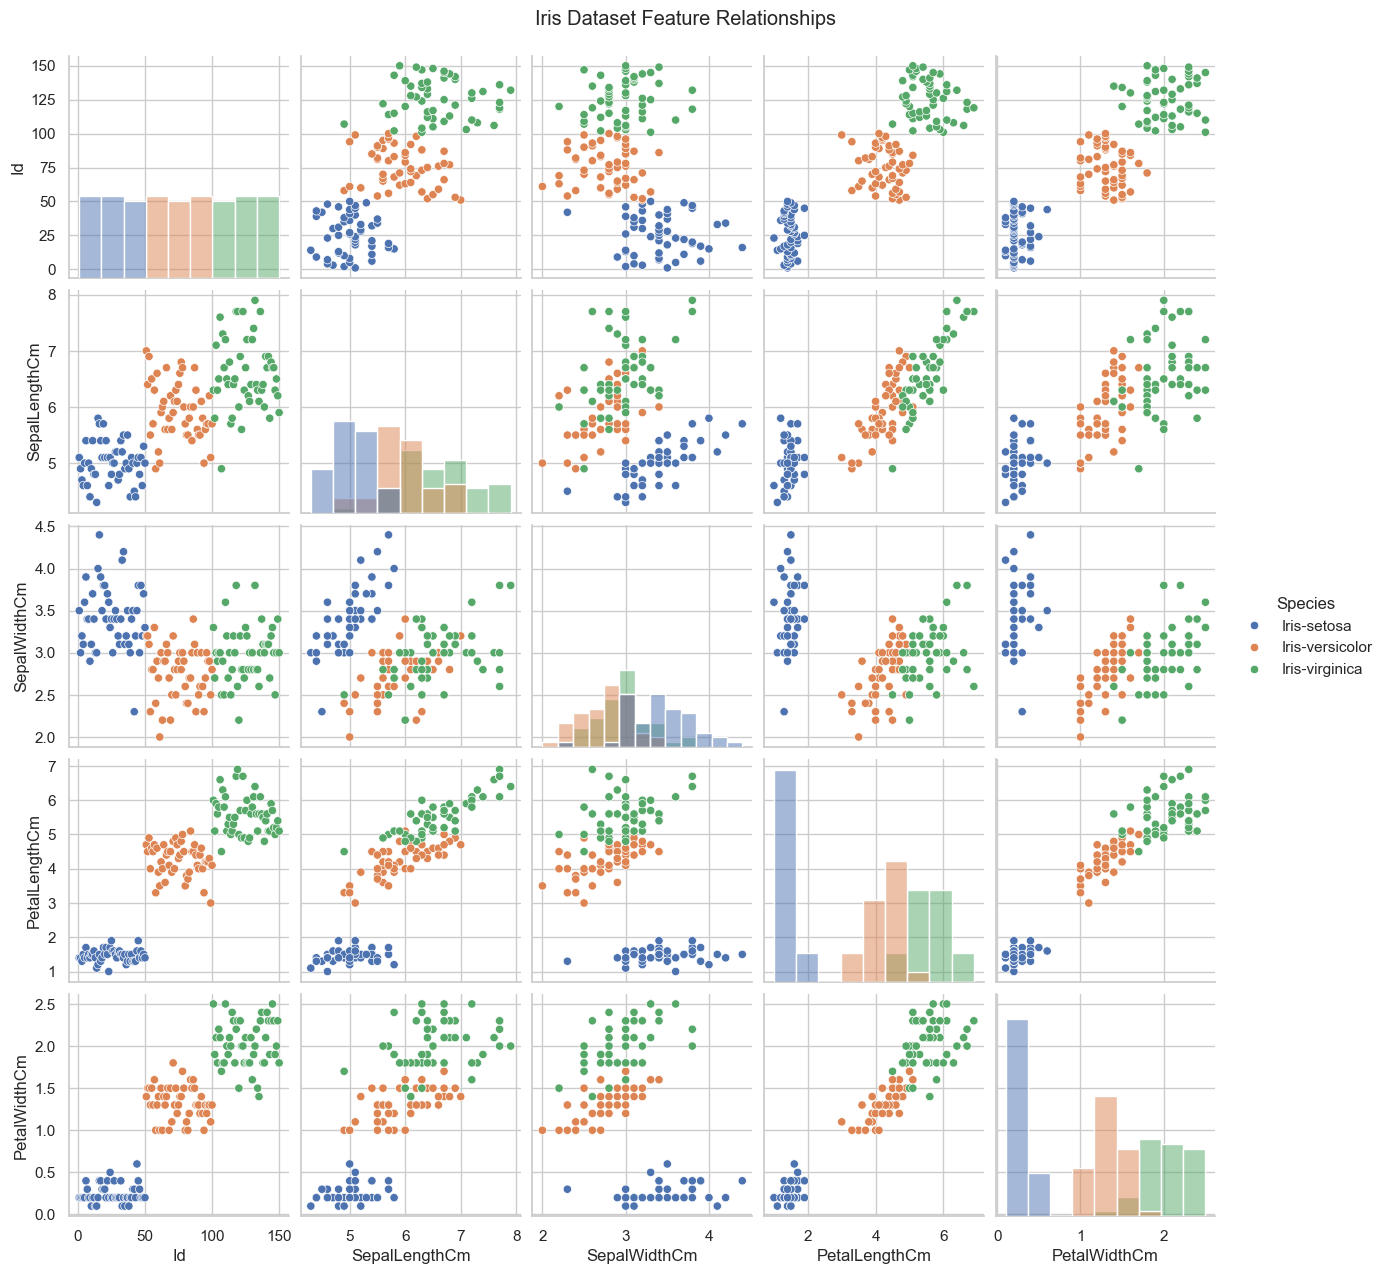

In [7]:
sns.pairplot(df, hue='Species', diag_kind='hist')
plt.suptitle('Iris Dataset Feature Relationships', y=1.02)
plt.show()


## 4. Select Features and Target Labels


In [8]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[features].copy()

# Used only for evaluation, not for fitting K-Means
y = df['Species'].astype('category').cat.codes
class_names = list(df['Species'].astype('category').cat.categories)

print('Features used for clustering:')
print(features)
print('\nSpecies classes:')
print(class_names)


Features used for clustering:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Species classes:
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 5. Standardize the Features


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Standardized feature matrix shape:', X_scaled.shape)


Standardized feature matrix shape: (150, 4)


## 6. Elbow Method


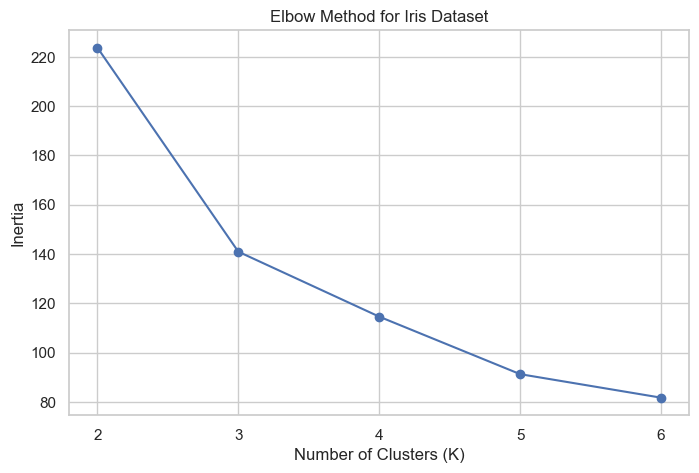

In [10]:
k_values = range(2, 7)
inertia = []

for k in k_values:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia, marker='o')
plt.title('Elbow Method for Iris Dataset')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
plt.show()


## 7. Silhouette Score for Different K Values


In [11]:
silhouette_scores = {}

for k in k_values:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = model.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

silhouette_table = pd.DataFrame({
    'K': list(silhouette_scores.keys()),
    'Silhouette Score': list(silhouette_scores.values())
})

silhouette_table.round(4)


,K,Silhouette Score
0,2,0.5802
1,3,0.4590
2,4,0.3853
3,5,0.3473
4,6,0.3407


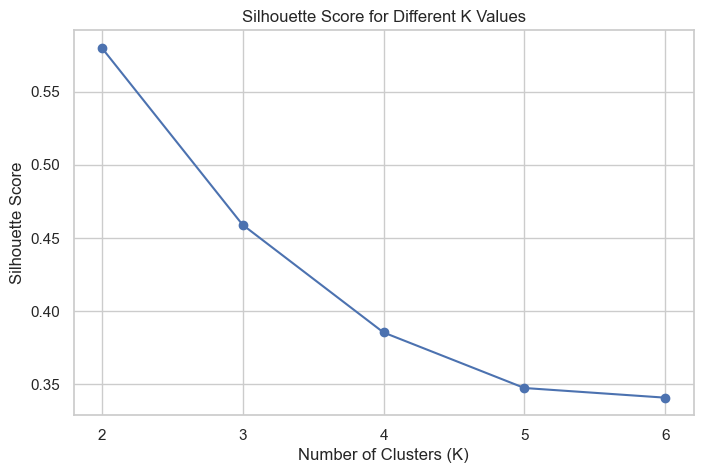

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.show()


## 8. Clustering Accuracy Against Known Iris Species

K-Means is unsupervised and does not use `Species` during fitting. For an illustrative comparison with the known Iris species, each cluster is mapped to its majority species and then accuracy is calculated.


In [13]:
accuracy_scores = {}
mapped_predictions = {}
models = {}

for k in k_values:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = model.fit_predict(X_scaled)
    models[k] = model

    mapped_labels = np.zeros_like(cluster_labels)

    for cluster in range(k):
        mask = cluster_labels == cluster
        if np.sum(mask) > 0:
            mapped_labels[mask] = mode(y[mask], keepdims=True).mode[0]

    accuracy_scores[k] = accuracy_score(y, mapped_labels)
    mapped_predictions[k] = mapped_labels

accuracy_table = pd.DataFrame({
    'K': list(accuracy_scores.keys()),
    'Accuracy': list(accuracy_scores.values()),
    'Accuracy (%)': [v * 100 for v in accuracy_scores.values()]
})

accuracy_table.round(4)


,K,Accuracy,Accuracy (%)
0,2,0.6667,66.6667
1,3,0.8333,83.3333
2,4,0.8467,84.6667
3,5,0.8533,85.3333
4,6,0.9133,91.3333


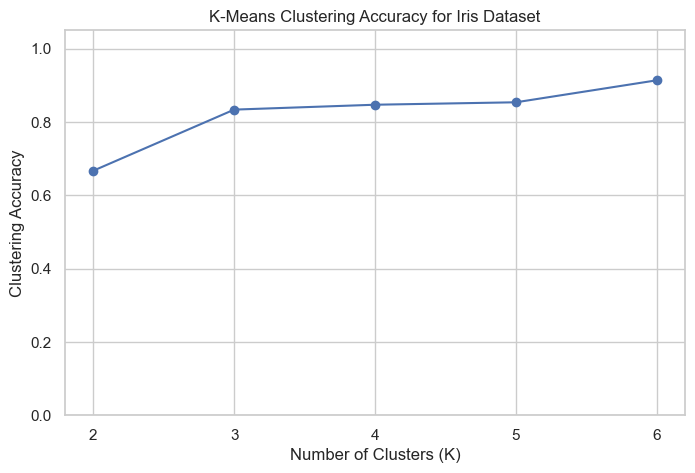

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(list(accuracy_scores.keys()), list(accuracy_scores.values()), marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Clustering Accuracy')
plt.title('K-Means Clustering Accuracy for Iris Dataset')
plt.xticks(list(k_values))
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()


## 9. Final K-Means Model – K = 3

The Iris dataset contains three known species. Therefore, **K = 3** is used for the final clustering model.


In [15]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_scaled)
final_mapped_labels = mapped_predictions[optimal_k]

final_accuracy = accuracy_score(y, final_mapped_labels)
final_silhouette = silhouette_score(X_scaled, cluster_labels)

print('Final Number of Clusters (K):', optimal_k)
print('Final Accuracy:', round(final_accuracy * 100, 2), '%')
print('Final Silhouette Score:', round(final_silhouette, 4))
print('Final Inertia:', round(kmeans.inertia_, 4))


Final Number of Clusters (K): 3
Final Accuracy: 83.33 %
Final Silhouette Score: 0.459
Final Inertia: 140.9658


## 10. Confusion Matrix – K = 3


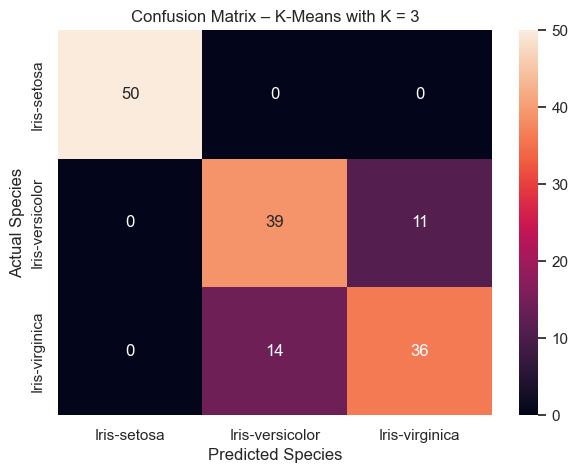

In [16]:
cm = confusion_matrix(y, final_mapped_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix – K-Means with K = 3')
plt.show()


## 11. Add Cluster Labels to the Dataset


In [17]:
result = df.copy()
result['Cluster'] = cluster_labels
result['Mapped_Species'] = [class_names[i] for i in final_mapped_labels]

result.head(10)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster,Mapped_Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa,1,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa,1,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa,1,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa,1,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa,1,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa,1,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa,1,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa,1,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa,1,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa,1,Iris-setosa


In [18]:
cluster_counts = result['Cluster'].value_counts().sort_index()
print('Number of samples in each cluster:')
print(cluster_counts)


Number of samples in each cluster:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64


## 12. Cluster Visualization Using PCA


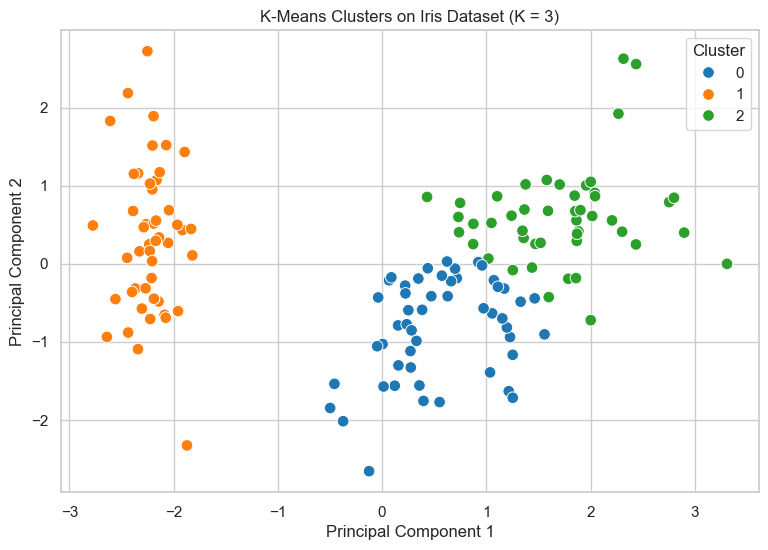

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels
pca_df['Species'] = df['Species'].values

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    s=70
)
plt.title('K-Means Clusters on Iris Dataset (K = 3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


## 13. Compare Actual Species and K-Means Clusters


In [20]:
comparison = pd.crosstab(
    result['Species'],
    result['Cluster']
)
comparison


Cluster,0,1,2
Species,,,
Iris-setosa,0,50,0
Iris-versicolor,39,0,11
Iris-virginica,14,0,36


## 14. Final Results


In [21]:
final_results = pd.DataFrame({
    'Parameter': [
        'Dataset',
        'Number of Samples',
        'Number of Features',
        'Final K',
        'Final Accuracy (%)',
        'Final Silhouette Score',
        'Final Inertia'
    ],
    'Value': [
        'Iris',
        len(df),
        len(features),
        optimal_k,
        round(final_accuracy * 100, 2),
        round(final_silhouette, 4),
        round(kmeans.inertia_, 4)
    ]
})

final_results


,Parameter,Value
0,Dataset,Iris
1,Number of Samples,150
2,Number of Features,4
3,Final K,3
4,Final Accuracy (%),83.33
5,Final Silhouette Score,0.459
6,Final Inertia,140.9658


In [22]:
import pickle
pickle_data = {
    "model": kmeans,
    "scaler": scaler,
    "features": features
}
with open("iris_kmeans_model.pkl", "wb") as file:
    pickle.dump(pickle_data, file)

print("✅ Pickle file created successfully!")
print("📁 File: iris_kmeans_model.pkl")

✅ Pickle file created successfully!
📁 File: iris_kmeans_model.pkl


## 15. Conclusion

1. The Iris dataset was loaded and explored.
2. The four numerical measurements were standardized before clustering.
3. K-Means was evaluated for multiple values of K.
4. The Elbow Method and Silhouette Score were used as clustering diagnostics.
5. The known Iris species were used only for post-hoc evaluation.
6. **K = 3** was selected as the final clustering configuration because Iris contains three known species.
7. The final clusters were compared with the known species using majority-label mapping, accuracy and a confusion matrix.
8. PCA was used to visualize the three clusters.

**Final result:** The notebook uses **K = 3** as the final Iris K-Means model and reports its corresponding accuracy and clustering metrics.


### Important Note

K-Means cluster IDs are arbitrary, so direct comparison of raw cluster numbers with species codes is not valid without label mapping. Also, clustering accuracy is a post-hoc agreement measure when ground-truth labels are available; it is not the same as the unsupervised silhouette score.
